## 1. What this notebook computes

Every formula of the course is written in *index notation*: a letter such as $a$
or $\mu$ stands for each of the eight coordinates $x_1, \dots, x_8$ of the
author's spacetime, and a letter that appears twice is summed. This notebook
teaches that notation from zero and uses it on the objects of the theory. It

- shows free and dummy indices and the summation convention with numpy's
  function `einsum`, which reads the convention literally;
- reads the frame metric $\eta$ from the Revision record, lowers and raises
  indices with it, and checks $\eta^{ab}\eta_{bc} = \delta^a_c$ and
  $\delta^a_a = 8$;
- computes squared lengths $\eta_{ab} v^a v^b$ and sorts vectors into
  space-like, time-like and light-like ones; with four space-like and four
  time-like directions exactly half of all random vectors are space-like, unlike
  in ordinary four-dimensional spacetime;
- proves that a symmetric array contracted with an antisymmetric one gives 0;
- checks the Clifford relation $\gamma^a \gamma^b + \gamma^b \gamma^a =
  2\eta^{ab} I$ of the eight real gamma matrices of the Revision record: one
  index formula that stands for 64 matrix equations;
- derives and checks the contractions $\gamma^a \gamma_a = 8 I$ and
  $\gamma^a \gamma^b \gamma_a = -6 \gamma^b$;
- writes the squared length of a small coordinate step in the author's metric
  as a sum over indices, and shows how the growth of space and the exponential
  deflation of the three extra times change it.

Every check prints a line that starts with PASS; where a check repeats a result
of the Revision record, a second line names the record file and its check.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 01e (Index notation, the summation convention and the metric) is the file
`Revision/textbook/notebooks/01e_index_notation.ipynb` of the repository Dirac_claude. It
teaches free and dummy indices and the summation convention with numpy einsum, reads the
frame metric eta of the author's coordinates x1 to x8 from the Revision record, lowers
and raises indices with it, sorts vectors into space-like, time-like and light-like ones
in the signature (4,4) and compares random vectors with those of ordinary
four-dimensional spacetime, proves that a symmetric array contracted with an
antisymmetric one gives zero, checks the Clifford relation of the eight real gamma
matrices of the Revision record as one index formula for all 64 pairs, derives and checks
the contractions gamma^a gamma_a = 8 and gamma^a gamma^b gamma_a = -6 gamma^b, and writes
the squared length of a coordinate step in the author's metric, whose three extra times
deflate exponentially, as a sum over indices, with heat maps and plots. It needs a
computer with Windows 11, macOS or Linux, an internet connection for the installation,
the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
and nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other
packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 01e_index_notation.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 01e_index_notation.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
01e_index_notation.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/01e.captions.json`
- `Revision/textbook/figures/01e_1_eta_and_delta.png`
- `Revision/textbook/figures/01e_2_squared_lengths.png`
- `Revision/textbook/figures/01e_3_symmetric_antisymmetric.png`
- `Revision/textbook/figures/01e_4_clifford_tables.png`
- `Revision/textbook/figures/01e_5_gamma_contractions.png`
- `Revision/textbook/figures/01e_6_step_length.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all 6 figure files of this notebook exist
    ALL 25 CHECKS PASSED (notebook 01e)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/01e_index_notation.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 01e_index_notation.ipynb
      python -m nbconvert --execute --inplace 01e_index_notation.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for a file below Revision/algebra or Revision/gkd_lovelock: the
  notebook reads Revision records of the repository; your copy of the repository is
  incomplete. Download it again with git clone and open the notebook inside the new copy.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 01e (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 01e (Index notation, the summation convention and the metric) is the file
# Revision/textbook/notebooks/01e_index_notation.ipynb of the repository Dirac_claude. It
# teaches free and dummy indices and the summation convention with numpy einsum, reads
# the frame metric eta of the author's coordinates x1 to x8 from the Revision record,
# lowers and raises indices with it, sorts vectors into space-like, time-like and
# light-like ones in the signature (4,4) and compares random vectors with those of
# ordinary four-dimensional spacetime, proves that a symmetric array contracted with an
# antisymmetric one gives zero, checks the Clifford relation of the eight real gamma
# matrices of the Revision record as one index formula for all 64 pairs, derives and
# checks the contractions gamma^a gamma_a = 8 and gamma^a gamma^b gamma_a = -6 gamma^b,
# and writes the squared length of a coordinate step in the author's metric, whose three
# extra times deflate exponentially, as a sum over indices, with heat maps and plots. It
# needs a computer with Windows 11, macOS or Linux, an internet connection for the
# installation, the program Git, and Python 3.12 or newer (the notebooks were built with
# Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
# 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
# 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy
# and matplotlib; the other packages run Jupyter, the program that shows and runs
# notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 01e_index_notation.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 01e_index_notation.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 01e_index_notation.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/01e.captions.json
# - Revision/textbook/figures/01e_1_eta_and_delta.png
# - Revision/textbook/figures/01e_2_squared_lengths.png
# - Revision/textbook/figures/01e_3_symmetric_antisymmetric.png
# - Revision/textbook/figures/01e_4_clifford_tables.png
# - Revision/textbook/figures/01e_5_gamma_contractions.png
# - Revision/textbook/figures/01e_6_step_length.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all 6 figure files of this notebook exist
#     ALL 25 CHECKS PASSED (notebook 01e)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/01e_index_notation.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 01e_index_notation.ipynb
#     python -m nbconvert --execute --inplace 01e_index_notation.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for a file below Revision/algebra or Revision/gkd_lovelock: the
#   notebook reads Revision records of the repository; your copy of the repository is
#   incomplete. Download it again with git clone and open the notebook inside the new
#   copy.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "01e"  # this notebook: chapter 01, example e


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 01e complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Index**: a letter ($a, b, c, d$ or $\mu, \nu, \lambda$) that stands for one
  of the eight coordinates $x_1, \dots, x_8$; the component of a vector $v$
  along $x_3$ is written $v^3$. Python numbers the same components 0 to 7, so
  $v^3$ is `v[2]`.
- **Upper and lower index**: $v^a$ and $v_a$ are two lists of eight numbers
  that belong to the same vector (section 6 says how one is made from the
  other). An upper index is a label, not a power: $v^3$ is a component, and its
  square is written $(v^3)^2$.
- **Free index**: an index that appears once in every term of a formula; the
  formula holds for each of its values, so a formula with $k$ free indices over
  8 coordinates stands for $8^k$ equations.
- **Dummy index**: an index that appears twice in one term, once up and once
  down; it is summed over all its values. Its name does not matter.
- **Summation convention** (Einstein's): the rule that a repeated index is
  summed without writing $\sum$: $v^a w_a = \sum_{a} v^a w_a$.
- **einsum**: numpy's function that evaluates such a sum from a text that lists
  the indices of every factor, for example `np.einsum("ab,b->a", M, v)`.
- **Contraction**: setting an upper and a lower index equal and summing over
  it, as in $\delta^a_a$ or $v^a w_a$.
- **Kronecker delta** $\delta^a_b$: 1 if $a = b$ and 0 otherwise; as a table it
  is the identity matrix $I$.
- **Frame metric** $\eta_{ab}$: the diagonal table
  $\mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$ in the order $x_1, \dots,
  x_8$; $\eta^{ab}$ (upper indices) is its inverse.
- **Lowering and raising**: $v_a = \eta_{ab} v^b$ and $v^a = \eta^{ab} v_b$.
- **Squared length** $Q(v) = \eta_{ab} v^a v^b$. A vector $v \neq 0$ is
  **space-like** if $Q > 0$, **time-like** if $Q < 0$ and **light-like** (or
  **null**) if $Q = 0$.
- **Signature** (4,4): $\eta$ has four entries $+1$ and four entries $-1$.
- **Symmetric** array: $S_{ab} = S_{ba}$; **antisymmetric** array:
  $A_{ab} = -A_{ba}$ (its diagonal is 0).
- **Commutator** $[P, R] = PR - RP$; **anticommutator** $\{P, R\} = PR + RP$.
- **Gamma matrices** $\gamma^a$: the eight real $16 \times 16$ matrices of the
  author's theory, one for each coordinate, stored in the Revision record; they
  obey the **Clifford relation** $\{\gamma^a, \gamma^b\} = 2\eta^{ab} I$.
- **Orthogonal matrix**: a real matrix $O$ with $O^T O = I$, so $O^T = O^{-1}$.
- **Trace** $\mathrm{tr}\,M$: the sum of the diagonal entries of a matrix; it
  obeys $\mathrm{tr}(PR) = \mathrm{tr}(RP)$.
- **Metric** $g_{\mu\nu}$ and **line element**: the author's metric turns a
  small coordinate step $dx^\mu$ into the squared length
  $ds^2 = g_{\mu\nu} dx^\mu dx^\nu$.
- **Normal random numbers**: random numbers whose histogram is the bell curve
  $e^{-x^2/2}/\sqrt{2\pi}$; numpy's `normal` draws them.
- **Histogram**: bars that show how many numbers fall into each interval.

## 4. The physical and mathematical situation

The author's spacetime has eight coordinates: $x_1, x_2, x_3$ are ordinary
space, $x_4$ is the time, $x_5, x_6, x_7$ are three extra times, and $x_8$ is a
hidden space direction. The *frame metric*

$$\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$$

records only which directions are space-like ($+1$: $x_1, x_2, x_3, x_8$) and
which are time-like ($-1$: $x_4, \dots, x_7$). The full *metric* of the
primordial gravitational field is

$$g = \mathrm{diag}\big(e^{2a_4} s, e^{2a_4} s, e^{2a_4} s, -1,
-e^{-2a_4} s, -e^{-2a_4} s, -e^{-2a_4} s, \cot^2 z\big),\quad
s = \sin^{1/3} z,\ z = 6 H x_8,$$

with a positive constant $H$, $0 < z < \pi/2$, and a function $a_4(x_4)$ of the
time: as $a_4$ grows, the lengths along $x_1, x_2, x_3$ grow like $e^{a_4}$ and
the lengths along the three extra times shrink like $e^{-a_4}$, that is, they
deflate exponentially.

Each equation of the theory is an index formula. For example the field
equation of the Revision record, $\gamma^\mu D_\mu \Psi = (m + U'(S))\Psi$, is a
sum over $\mu$ of eight terms, and the Clifford relation
$\gamma^a \gamma^b + \gamma^b \gamma^a = 2\eta^{ab} I$ is one line that stands
for $8 \cdot 8 = 64$ equations between $16 \times 16$ matrices. Reading and
checking such formulas is the skill this notebook trains.

## 5. Free and dummy indices

The next cell works with a $3 \times 3$ table $M^a{}_b$ (row $a$, column $b$) and
the vector $v^b = (2, -1, 3)$. In

$$w^a = M^a{}_b v^b = \sum_{b} M^a{}_b v^b$$

the index $a$ is free (one equation for each $a$) and $b$ is a dummy (summed).
The cell computes $w$ three ways: with loops; with
`np.einsum("ab,b->a", M, v)`, whose text says "the first factor has the indices
$a, b$, the second $b$; $b$ appears twice, so it is summed; the result keeps
$a$"; and with the dummy renamed to $c$, which changes nothing. Row 1 gives
$1 \cdot 2 + 2 \cdot (-1) + 0 \cdot 3 = 0$, row 2 gives $0 - 1 + 3 = 2$, row 3
gives $2 - 3 + 3 = 2$.

It then computes two numbers without any free index: the trace
$M^a{}_a = 1 + 1 + 1 = 3$ (a contraction of the two indices of one table) and
$u_a M^a{}_b v^b$ for $u_a = (1, 0, 2)$, which has two dummy indices; since
$M^a{}_b v^b = (0, 2, 2)$, it is $1 \cdot 0 + 0 \cdot 2 + 2 \cdot 2 = 4$.
Finally it prints how many equations a formula with 0 to 3 free indices over
the eight coordinates stands for.

In [2]:
import itertools  # all pairs (a, b) of indices
import math  # pi and square roots of plain numbers

import numpy as np  # arrays and einsum
import sympy as sp  # exact algebra with symbols

M = np.array([[1, 2, 0],
              [0, 1, 1],
              [1, 3, 1]])  # the entries M^a_b: row a, column b
v = np.array([2, -1, 3])  # the components v^b
u = np.array([1, 0, 2])  # the components u_a of a second vector
# w^a = M^a_b v^b: the free index a is kept, the dummy index b is summed.
w_loops = [sum(int(M[a, b]) * int(v[b]) for b in range(3)) for a in range(3)]
w_einsum = np.einsum("ab,b->a", M, v)  # "b" appears twice: it is summed
w_renamed = np.einsum("ac,c->a", M, v)  # the dummy renamed to c: the same sum
say(f"w = M v by loops {w_loops}, by einsum {w_einsum.tolist()}, with the dummy "
    f"renamed {w_renamed.tolist()}")
check(w_loops == w_einsum.tolist() == w_renamed.tolist() == (M @ v).tolist()
      == [0, 2, 2],
      "loops, einsum and @ give w = (0, 2, 2); renaming the dummy changes nothing")
trace = int(np.einsum("aa->", M))  # M^a_a: the repeated index a is summed
full = int(np.einsum("a,ab,b->", u, M, v))  # u_a M^a_b v^b: two dummies, no free
say(f"M^a_a = {trace}, u_a M^a_b v^b = {full}")
check(trace == int(np.trace(M)) == 3 and full == int(u @ M @ v) == 4,
      "the trace M^a_a = 3 and the number u_a M^a_b v^b = 4")
for free in range(4):
    word = "equation" if free == 0 else "equations"  # 8^0 = 1 equation
    say(f"{free} free indices over the 8 coordinates: 8^{free} = {8 ** free} {word}")

w = M v by loops [0, 2, 2], by einsum [0, 2, 2], with the dummy renamed [0, 2, 2]
PASS loops, einsum and @ give w = (0, 2, 2); renaming the dummy changes nothing
M^a_a = 3, u_a M^a_b v^b = 4
PASS the trace M^a_a = 3 and the number u_a M^a_b v^b = 4
0 free indices over the 8 coordinates: 8^0 = 1 equation
1 free indices over the 8 coordinates: 8^1 = 8 equations
2 free indices over the 8 coordinates: 8^2 = 64 equations
3 free indices over the 8 coordinates: 8^3 = 512 equations


## 6. The frame metric: lowering and raising an index

The next cell reads the coordinate names and the diagonal of $\eta$ from the
Revision record file Revision/algebra/gammas.json, and the record's report
Revision/algebra/reports/python-algebra.json, whose check `coordinate_map`
states $\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$. Then:

- $\eta_{ab}$ is the diagonal matrix with these entries. Its inverse
  $\eta^{ab}$ is the diagonal matrix of the inverses $1/(+1) = +1$ and
  $1/(-1) = -1$: the same entries.
- $\eta^{ab}\eta_{bc}$ (free indices $a$ up and $c$ down, dummy $b$) must be
  $\delta^a_c$, and contracting the two indices of $\delta$ counts the
  coordinates: $\delta^a_a = 1 + 1 + \dots + 1 = 8$.
- Lowering the index of $v^a = (1, 2, \dots, 8)$ gives
  $v_a = \eta_{ab} v^b$; because $\eta$ is diagonal, only the term $b = a$ of
  the sum survives, $v_a = \eta_{aa} v^a$ (no sum here): the four time-like
  components $x_4, \dots, x_7$ change sign. Raising again,
  $\eta^{ab} v_b$, gives back $v^a$, because $\eta^{ab}\eta_{bc} = \delta^a_c$.

The cell after it defines the helper `heat_map`, which draws a table as
coloured squares (red positive, white zero, blue negative), and draws
$\eta_{ab}$, $\delta^a_c$ and the two lists $v^a$ and $v_a$.

In [3]:
algebra = json.loads(repository_file("Revision/algebra/gammas.json")
                     .read_text(encoding="utf-8"))
names = algebra["coordinates"]  # ["x1", "x2", ..., "x8"]
eta_diagonal = algebra["eta"]  # the diagonal of eta in the order x1 ... x8
algebra_report = json.loads(repository_file(
    "Revision/algebra/reports/python-algebra.json").read_text(encoding="utf-8"))
verdicts = {c["name"]: c["verdict"] for c in algebra_report["checks"]}
map_verdict = verdicts["coordinate_map"]  # "pass" in the record
say(f"coordinates {names}")
say(f"diagonal of eta {eta_diagonal}; record check coordinate_map: {map_verdict}")
check(eta_diagonal == [1, 1, 1, -1, -1, -1, -1, 1]
      and verdicts["coordinate_map"] == "pass",
      "eta = diag(+1, +1, +1, -1, -1, -1, -1, +1) in the order x1 ... x8",
      record="Revision/algebra/reports/python-algebra.json, check coordinate_map")
eta_lower = np.diag(eta_diagonal)  # eta_ab as an 8 x 8 matrix
eta_upper = np.diag([1 // e for e in eta_diagonal])  # eta^ab: 1/(+1) = 1, 1/(-1) = -1
delta = np.einsum("ab,bc->ac", eta_upper, eta_lower)  # eta^ab eta_bc
check((delta == np.eye(8, dtype=int)).all() and int(np.einsum("aa->", delta)) == 8,
      "eta^ab eta_bc = delta^a_c, and the contraction delta^a_a = 8")
v_up = np.arange(1, 9)  # v^a = 1, 2, ..., 8
v_down = np.einsum("ab,b->a", eta_lower, v_up)  # v_a = eta_ab v^b
v_back = np.einsum("ab,b->a", eta_upper, v_down)  # eta^ab v_b
flipped = [names[a] for a in range(8) if v_down[a] != v_up[a]]
say(f"v^a = {v_up.tolist()}")
say(f"v_a = {v_down.tolist()}; the components that changed sign: {flipped}")
check(flipped == ["x4", "x5", "x6", "x7"] and (v_back == v_up).all(),
      "lowering flips the signs of the time-like x4 ... x7; raising undoes it")

coordinates ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8']
diagonal of eta [1, 1, 1, -1, -1, -1, -1, 1]; record check coordinate_map: pass
PASS eta = diag(+1, +1, +1, -1, -1, -1, -1, +1) in the order x1 ... x8
     reproduces Revision/algebra/reports/python-algebra.json, check coordinate_map
PASS eta^ab eta_bc = delta^a_c, and the contraction delta^a_a = 8
v^a = [1, 2, 3, 4, 5, 6, 7, 8]
v_a = [1, 2, 3, -4, -5, -6, -7, 8]; the components that changed sign: ['x4', 'x5', 'x6',
    'x7']
PASS lowering flips the signs of the time-like x4 ... x7; raising undoes it


The next cell defines `heat_map` and draws the first figure: $\eta_{ab}$,
$\delta^a_c$ and the two lists $v^a$ and $v_a$ side by side.

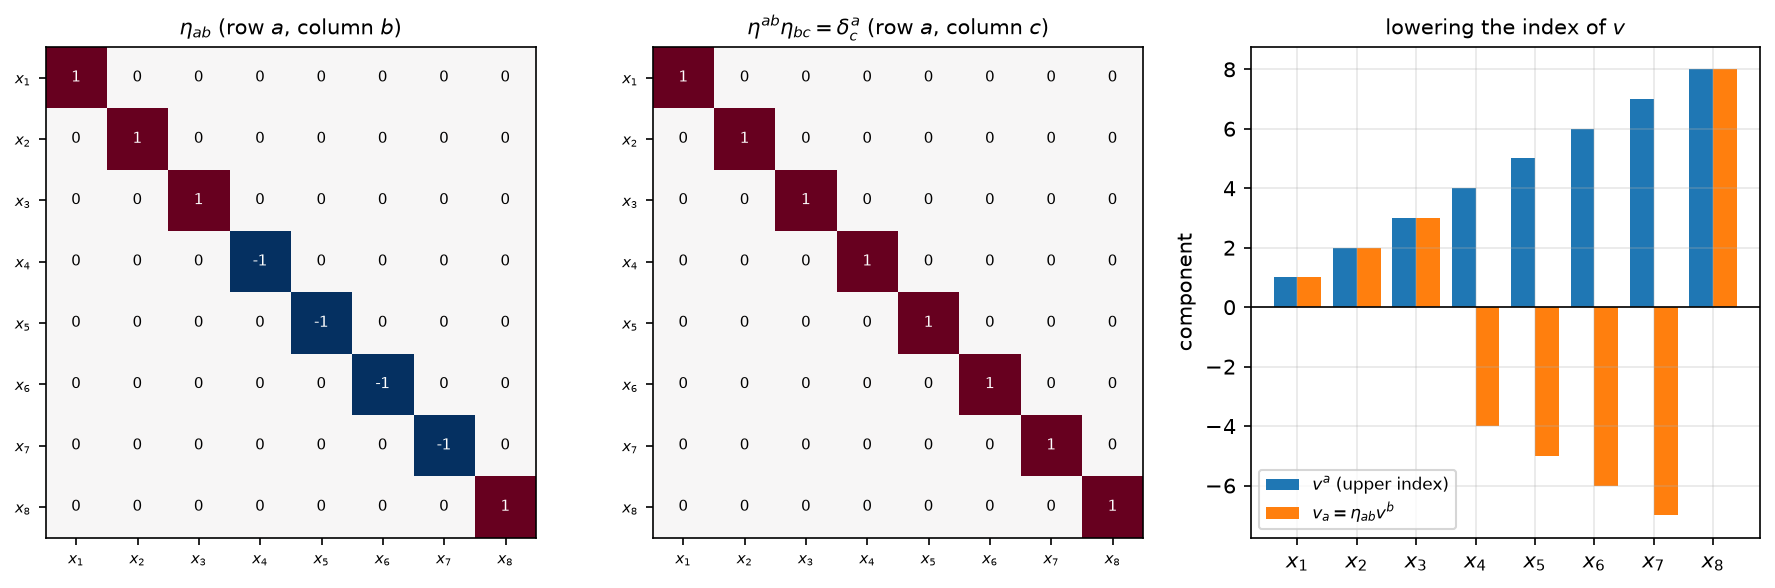

Figure 01e.1 saved as Revision/textbook/figures/01e_1_eta_and_delta.png


In [4]:
labels = [f"$x_{k}$" for k in range(1, 9)]  # x with the subscripts 1 ... 8


def heat_map(ax, matrix, title, ticks=labels, annotate=True, size=7.0):
    """Draw matrix on the axes ax: red positive, white zero, blue negative; with
    annotate the value is written in its square (%g: no needless digits)."""
    m = np.asarray(matrix, dtype=float)
    limit = max(1.0, float(np.abs(m).max()))  # colours from -limit to +limit
    ax.imshow(m, cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.grid(False)  # no grid lines across the coloured squares
    ax.set_xticks(range(m.shape[1]), ticks[:m.shape[1]], fontsize=7)
    ax.set_yticks(range(m.shape[0]), ticks[:m.shape[0]], fontsize=7)
    ax.set_title(title, fontsize=10)
    if annotate:
        for i in range(m.shape[0]):
            for j in range(m.shape[1]):
                ink = "white" if abs(m[i, j]) > 0.6 * limit else "black"
                ax.text(j, i, f"{m[i, j]:g}", ha="center", va="center",
                        fontsize=size, color=ink)


fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.0))
heat_map(axes[0], eta_lower, "$\\eta_{ab}$ (row $a$, column $b$)")
heat_map(axes[1], delta, "$\\eta^{ab}\\eta_{bc} = \\delta^a_c$ (row $a$, column $c$)")
positions = np.arange(8)
axes[2].bar(positions - 0.2, v_up, width=0.4, label="$v^a$ (upper index)")
axes[2].bar(positions + 0.2, v_down, width=0.4, label="$v_a = \\eta_{ab} v^b$")
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_xticks(positions, labels)
axes[2].set_ylabel("component")
axes[2].set_title("lowering the index of $v$", fontsize=10)
axes[2].legend(fontsize=8, loc="lower left")
fig.tight_layout()
save_figure(fig, "eta_and_delta",
            "Left: the frame metric $\\eta_{ab}$ of the author's coordinates as a "
            "heat map (rows $a$ and columns $b$ labelled $x_1$ to $x_8$; red $+1$, "
            "blue $-1$, white 0): $+1$ for the space-like $x_1, x_2, x_3, x_8$ and "
            "$-1$ for the time-like $x_4$ to $x_7$. Middle: the contraction "
            "$\\eta^{ab}\\eta_{bc}$, which is the identity matrix $\\delta^a_c$. "
            "Right: the components $v^a = 1, 2, \\dots, 8$ of a vector (blue) and "
            "the components $v_a = \\eta_{ab} v^b$ with the index lowered "
            "(orange); horizontal axis the coordinate, vertical axis the component "
            "(pure numbers). Lowering changes the sign of exactly the four "
            "time-like components.")

## 7. Squared lengths in the signature (4,4)

The squared length of a vector is

$$Q(v) = \eta_{ab} v^a v^b = v^a v_a = (v^1)^2 + (v^2)^2 + (v^3)^2 - (v^4)^2
- (v^5)^2 - (v^6)^2 - (v^7)^2 + (v^8)^2,$$

where the second form uses $v_a = \eta_{ab} v^b$, and the third writes out the
sum (only the terms $a = b$ survive because $\eta$ is diagonal). The next cell
defines `squared_length`, which evaluates $\eta_{ab} v^a v^b$ for many vectors
at once (`einsum("na,ab,nb->n", ...)`: $n$ numbers the vectors and is kept;
$a$ and $b$ are summed), and sorts five examples:

- the unit vector along $x_1$: $Q = +1$, space-like;
- the unit vector along $x_5$: $Q = -1$, time-like;
- their sum: $Q = 1 - 1 = 0$, light-like although it is not zero;
- $(1, 1, \dots, 1)$: $Q = 4 - 4 = 0$, light-like as well;
- $v^a = (1, 2, \dots, 8)$: $Q = 1 + 4 + 9 + 64 - 16 - 25 - 36 - 49 = -48$,
  time-like.

It checks the sorting and that $\eta_{ab} v^a v^b$ equals $v^a v_a$ for the last
example (the list $v_a$ of section 6).

In [5]:
def squared_length(vectors, metric_diagonal):
    """eta_ab v^a v^b for every row v of the array vectors (a and b are summed;
    the index n, which numbers the rows, is kept)."""
    metric = np.diag(metric_diagonal)
    return np.einsum("na,ab,nb->n", vectors, metric, vectors)


unit = np.eye(8, dtype=int)  # row k is the unit vector along x_(k+1)
examples = {"e(x1)": unit[0], "e(x5)": unit[4], "e(x1) + e(x5)": unit[0] + unit[4],
            "(1, 1, 1, 1, 1, 1, 1, 1)": np.ones(8, dtype=int),
            "(1, 2, 3, 4, 5, 6, 7, 8)": v_up}
kinds = []
for name, vector in examples.items():
    q = int(squared_length(vector[None, :], eta_diagonal)[0])  # one row
    kind = "space-like" if q > 0 else ("time-like" if q < 0 else "light-like")
    kinds.append(kind)
    q_text = f"{q:+d}" if q != 0 else "0"  # a sign in front of nonzero values only
    say(f"v = {name}: eta_ab v^a v^b = {q_text}, {kind}")
check(kinds == ["space-like", "time-like", "light-like", "light-like", "time-like"]
      and int(squared_length(v_up[None, :], eta_diagonal)[0]) == int(v_up @ v_down)
      == -48,
      "the five examples are sorted correctly, and eta_ab v^a v^b = v^a v_a = -48")

v = e(x1): eta_ab v^a v^b = +1, space-like
v = e(x5): eta_ab v^a v^b = -1, time-like
v = e(x1) + e(x5): eta_ab v^a v^b = 0, light-like
v = (1, 1, 1, 1, 1, 1, 1, 1): eta_ab v^a v^b = 0, light-like
v = (1, 2, 3, 4, 5, 6, 7, 8): eta_ab v^a v^b = -48, time-like
PASS the five examples are sorted correctly, and eta_ab v^a v^b = v^a v_a = -48


How many vectors are space-like? Draw the eight components of a vector as
independent normal random numbers. Exchange its four space-like components
$(v^1, v^2, v^3, v^8)$ with its four time-like components
$(v^4, v^5, v^6, v^7)$: the new vector $v'$ has

$$Q(v') = (v^4)^2 + (v^5)^2 + (v^6)^2 + (v^7)^2 - (v^1)^2 - (v^2)^2 - (v^3)^2
- (v^8)^2 = -Q(v),$$

because every square that was added is now subtracted and every square that
was subtracted is now added. The exchanged vector is exactly as likely as the
original one (all eight components are drawn the same way), so $Q > 0$ and
$Q < 0$ are equally likely, and $Q = 0$ exactly has probability 0: **in the
signature (4,4) exactly half of all random vectors are space-like.** In
ordinary spacetime with one time and three space directions, signature
(3,1), $Q = (v^1)^2 + (v^2)^2 + (v^3)^2 - (v^4)^2$ has three squares added
and one subtracted, and most random vectors are space-like; integral calculus
(not shown here) gives the fraction $1/2 + 1/\pi \approx 0.818$.

The next cell draws 200,000 random vectors (seed 12345), checks the exchange
rule on every one of them, measures both fractions and compares them with
$1/2$ and $1/2 + 1/\pi$, allowing 4 standard deviations
$\sqrt{p(1-p)/N}$ of a measured fraction $p$ from $N$ tries.

In [6]:
generator = np.random.default_rng(12345)  # random numbers with a fixed seed
samples = generator.normal(size=(200000, 8))  # 200,000 vectors of 8 components
q44 = squared_length(samples, eta_diagonal)  # signature (4,4)
space_part, time_part = [0, 1, 2, 7], [3, 4, 5, 6]  # x1 x2 x3 x8, and x4 ... x7
exchanged = samples.copy()
exchanged[:, space_part] = samples[:, time_part]  # time components -> space slots
exchanged[:, time_part] = samples[:, space_part]  # space components -> time slots
check(np.allclose(squared_length(exchanged, eta_diagonal), -q44, rtol=0, atol=1e-9),
      "exchanging the space-like and the time-like components turns Q into -Q "
      "(all 200000 vectors)")
fraction44 = float(np.mean(q44 > 0))  # the fraction of space-like vectors
q31 = squared_length(samples[:, :4], [1, 1, 1, -1])  # 3 space, 1 time direction
fraction31 = float(np.mean(q31 > 0))
exact31 = 0.5 + 1 / math.pi
sd44 = math.sqrt(0.5 * 0.5 / 200000)  # one standard deviation of a fraction
sd31 = math.sqrt(exact31 * (1 - exact31) / 200000)
report("fraction of space-like random vectors, signature (4,4)", f"{fraction44:.4f}")
report("fraction of space-like random vectors, signature (3,1)", f"{fraction31:.4f}")
check(abs(fraction44 - 0.5) < 4 * sd44,
      "signature (4,4): half of the random vectors are space-like")
check(abs(fraction31 - exact31) < 4 * sd31,
      "signature (3,1): the fraction is 1/2 + 1/pi = 0.818 (within 4 standard "
      "deviations)")

PASS exchanging the space-like and the time-like components turns Q into -Q (all 200000
    vectors)
RESULT fraction of space-like random vectors, signature (4,4) = 0.5031
RESULT fraction of space-like random vectors, signature (3,1) = 0.8177
PASS signature (4,4): half of the random vectors are space-like
PASS signature (3,1): the fraction is 1/2 + 1/pi = 0.818 (within 4 standard deviations)


The next cell draws the two histograms of $Q$: the signature (4,4) of the
author's spacetime and the signature (3,1) of ordinary spacetime.

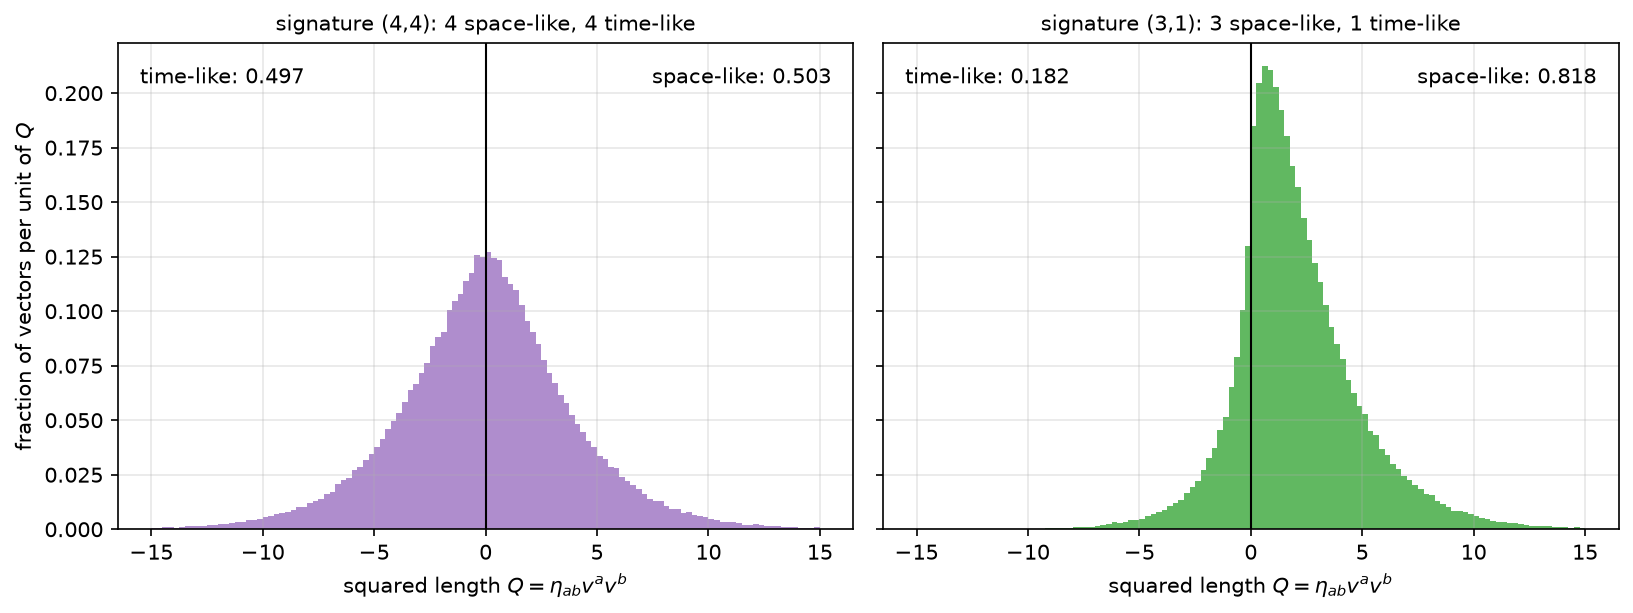

Figure 01e.2 saved as Revision/textbook/figures/01e_2_squared_lengths.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), sharey=True)
bins = np.linspace(-15.0, 15.0, 121)  # 120 intervals of width 0.25
for ax, values, fraction, title, color in (
        (axes[0], q44, fraction44, "signature (4,4): 4 space-like, 4 time-like",
         "tab:purple"),
        (axes[1], q31, fraction31, "signature (3,1): 3 space-like, 1 time-like",
         "tab:green")):
    ax.hist(values, bins=bins, density=True, color=color, alpha=0.75)
    ax.axvline(0.0, color="black", lw=1)
    ax.text(0.97, 0.95, f"space-like: {fraction:.3f}", transform=ax.transAxes,
            ha="right", va="top")
    ax.text(0.03, 0.95, f"time-like: {1 - fraction:.3f}", transform=ax.transAxes,
            ha="left", va="top")
    ax.set_xlabel("squared length $Q = \\eta_{ab} v^a v^b$")
    ax.set_title(title, fontsize=10)
axes[0].set_ylabel("fraction of vectors per unit of $Q$")
fig.tight_layout()
save_figure(fig, "squared_lengths",
            "Histograms of the squared length $Q = \\eta_{ab} v^a v^b$ of 200,000 "
            "random vectors whose components are normal random numbers; "
            "horizontal axis $Q$ (a pure number), vertical axis the fraction of "
            "vectors per unit of $Q$. Left: the signature (4,4) of the author's "
            "spacetime; the histogram is the same on both sides of $Q = 0$, so "
            "half of the vectors are space-like ($Q > 0$) and half time-like. "
            "Right: ordinary spacetime with one time and three space directions; "
            "about 82 per cent of the vectors are space-like.")

## 8. A symmetric array contracted with an antisymmetric one gives zero

Every square array $M_{ab}$ is a sum of a symmetric and an antisymmetric part:

$$M_{ab} = S_{ab} + A_{ab},\qquad S_{ab} = \tfrac12 (M_{ab} + M_{ba}),\qquad
A_{ab} = \tfrac12 (M_{ab} - M_{ba}).$$

Adding the two parts gives back $M_{ab}$ (the terms $M_{ba}$ cancel);
exchanging $a$ and $b$ leaves $S$ unchanged and changes the sign of $A$.

**Claim.** If $S_{ab} = S_{ba}$ and $A^{ab} = -A^{ba}$, then
$S_{ab} A^{ab} = 0$. **Proof**, line by line:

$$S_{ab} A^{ab} = S_{ba} A^{ba}$$

(both sides are the same sum over all pairs; the names of the two summed
indices were exchanged, which does not change a sum),

$$S_{ba} A^{ba} = S_{ab} \, (-A^{ab})$$

(the symmetry of $S$ and the antisymmetry of $A$), so
$S_{ab} A^{ab} = -S_{ab} A^{ab}$, and a number that equals its own negative is
0. In words: the term $(a, b)$ and the term $(b, a)$ cancel, and the diagonal
terms are 0.

Raising both indices keeps an array antisymmetric:
$A^{ab} = \eta^{ac}\eta^{bd} A_{cd}$, and
$A^{ba} = \eta^{bc}\eta^{ad} A_{cd} = \eta^{ad}\eta^{bc} A_{cd}$; renaming the
dummies $c \leftrightarrow d$ gives $\eta^{ac}\eta^{bd} A_{dc} =
-\eta^{ac}\eta^{bd} A_{cd} = -A^{ab}$.

A consequence used again and again: for a vector with ordinary (commuting)
components, $v^a v^b$ is symmetric in $a$ and $b$, so
$v^a v^b A_{ab} = 0$ and $v^a v^b M_{ab} = v^a v^b S_{ab}$: only the
symmetric part of an array counts in a squared expression. (Later in the course
the components of the field dirac16complex *anticommute*; then the opposite
holds, and only the antisymmetric part counts.)

The next cell checks all of this exactly, with whole numbers: it works with
$2S$ and $2A$, so that no fraction appears.

In [8]:
M8 = generator.integers(-5, 6, size=(8, 8))  # a random 8 x 8 array, entries -5 ... 5
S2 = M8 + M8.T  # twice the symmetric part
A2 = M8 - M8.T  # twice the antisymmetric part
check((S2 == S2.T).all() and (A2 == -A2.T).all() and (S2 + A2 == 2 * M8).all(),
      "M = S + A with S = (M + M^T)/2 symmetric and A = (M - M^T)/2 antisymmetric")
A2_up = np.einsum("ac,bd,cd->ab", eta_upper, eta_upper, A2)  # A^ab (times 2)
terms = S2 * A2_up  # the 64 terms S_ab A^ab (times 4), before the sum
total = int(np.einsum("ab,ab->", S2, A2_up))  # the full contraction (times 4)
say(f"4 S_ab A^ab = {total}; the largest single term is "
    f"{int(np.abs(terms).max())}")
check((A2_up == -A2_up.T).all() and (terms == -terms.T).all() and total == 0,
      "A^ab is antisymmetric, the terms (a, b) and (b, a) cancel, S_ab A^ab = 0")
all_zero = True
for _ in range(100):  # 100 more random pairs of arrays
    X = generator.integers(-9, 10, size=(8, 8))
    Y = generator.integers(-9, 10, size=(8, 8))
    all_zero &= int(np.einsum("ab,ac,bd,cd->", X + X.T, eta_upper, eta_upper,
                              Y - Y.T)) == 0
check(all_zero, "S_ab A^ab = 0 for 100 more random pairs of arrays")
squares_ok = True
for _ in range(100):  # 100 random vectors with whole-number components
    w8 = generator.integers(-9, 10, size=8)
    squares_ok &= int(np.einsum("a,b,ab->", w8, w8, A2)) == 0
    squares_ok &= (int(np.einsum("a,b,ab->", w8, w8, 2 * M8))
                   == int(np.einsum("a,b,ab->", w8, w8, S2)))
check(squares_ok, "v^a v^b A_ab = 0 and v^a v^b M_ab = v^a v^b S_ab (100 random "
      "vectors with commuting components)")

PASS M = S + A with S = (M + M^T)/2 symmetric and A = (M - M^T)/2 antisymmetric
4 S_ab A^ab = 0; the largest single term is 24
PASS A^ab is antisymmetric, the terms (a, b) and (b, a) cancel, S_ab A^ab = 0
PASS S_ab A^ab = 0 for 100 more random pairs of arrays
PASS v^a v^b A_ab = 0 and v^a v^b M_ab = v^a v^b S_ab (100 random vectors with commuting
    components)


The next cell draws the array $M_{ab}$, its symmetric part, its antisymmetric
part and the 64 terms $S_{ab} A^{ab}$ of the contraction, whose colours show
that each term is cancelled by its mirror image across the diagonal.

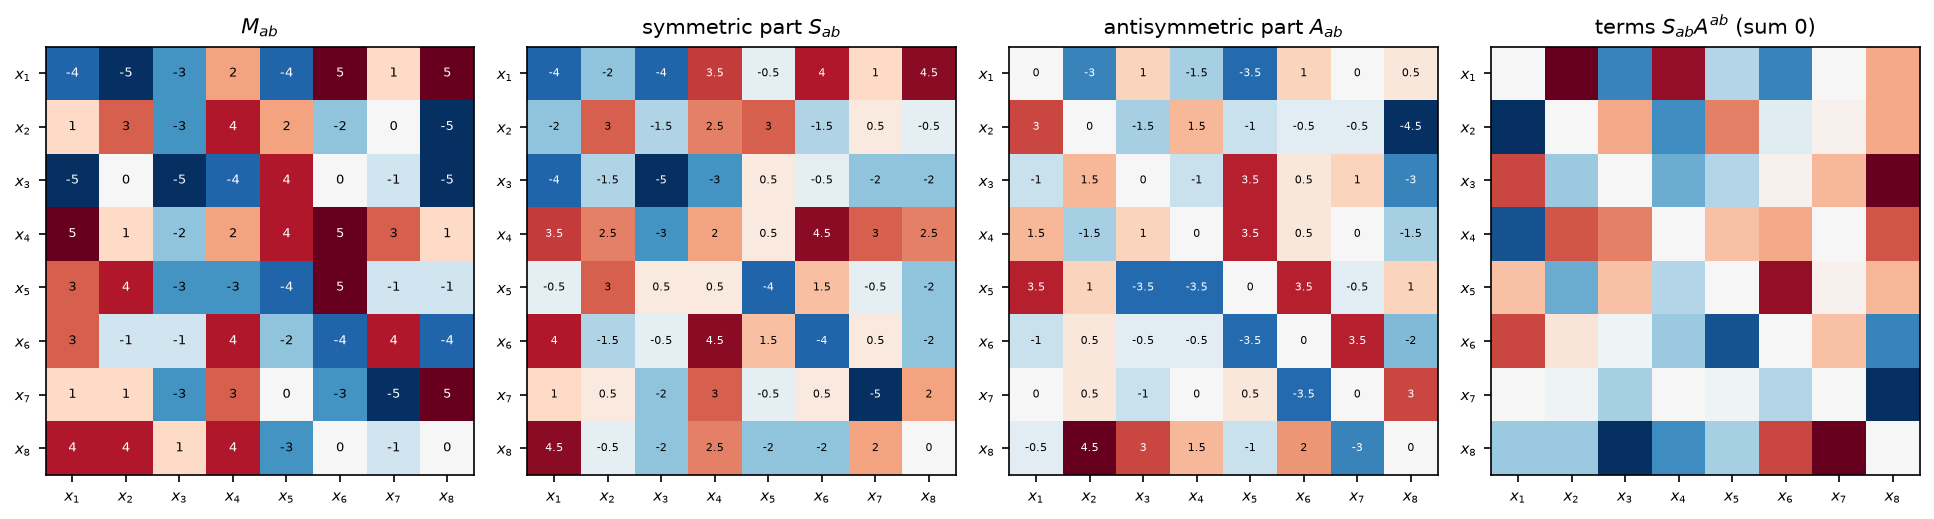

Figure 01e.3 saved as Revision/textbook/figures/01e_3_symmetric_antisymmetric.png


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(13.0, 3.7))
heat_map(axes[0], M8, "$M_{ab}$", size=6.0)
heat_map(axes[1], S2 / 2, "symmetric part $S_{ab}$", size=5.5)
heat_map(axes[2], A2 / 2, "antisymmetric part $A_{ab}$", size=5.5)
heat_map(axes[3], terms / 4, "terms $S_{ab} A^{ab}$ (sum 0)", annotate=False)
fig.tight_layout()
save_figure(fig, "symmetric_antisymmetric",
            "A random $8 \\times 8$ array $M_{ab}$ of whole numbers (left), its "
            "symmetric part $S_{ab} = (M_{ab} + M_{ba})/2$, its antisymmetric part "
            "$A_{ab} = (M_{ab} - M_{ba})/2$, and the 64 terms $S_{ab} A^{ab}$ of "
            "their contraction (right), as heat maps with rows $a$ and columns $b$ "
            "labelled $x_1$ to $x_8$ (red positive, white zero, blue negative). "
            "$S$ is mirror-symmetric across the diagonal, $A$ changes sign under "
            "the mirror and has a white diagonal, and every term of the "
            "contraction is cancelled by its mirror image, so the sum is 0.")

## 9. Commutators, anticommutators and the Clifford relation

For two square matrices $P$ and $R$ the commutator $[P, R] = PR - RP$ and the
anticommutator $\{P, R\} = PR + RP$ split the product into two parts:

$$PR = \tfrac12 [P, R] + \tfrac12 \{P, R\},$$

because the two halves add up to $\tfrac12 (PR - RP + PR + RP) = PR$; and
$[R, P] = -[P, R]$, $\{R, P\} = \{P, R\}$ directly from the definitions.

The eight gamma matrices obey the Clifford relation

$$\gamma^a \gamma^b + \gamma^b \gamma^a = 2\eta^{ab} I \qquad (a, b = x_1, \dots,
x_8).$$

It has two free indices, so it stands for 64 matrix equations: for $a = b$ it
says $(\gamma^a)^2 = \eta^{aa} I$ ($+I$ for a space-like and $-I$ for a time-like
direction); for $a \neq b$ it says that $\gamma^a$ and $\gamma^b$
anticommute, $\gamma^a \gamma^b = -\gamma^b \gamma^a$, so their commutator is
$2\gamma^a\gamma^b$.

A second fact follows from it. Each gamma matrix of the record is a signed
permutation matrix, so it is orthogonal: $(\gamma^a)^T \gamma^a = I$, that is
$(\gamma^a)^T = (\gamma^a)^{-1}$. And $(\gamma^a)^2 = \eta^{aa} I$ says
$(\gamma^a)^{-1} = \eta^{aa}\gamma^a$ (because $\eta^{aa} = \pm 1$ is its own
inverse). Together: $(\gamma^a)^T = \eta_{aa}\gamma^a$ (no sum; $\eta_{aa} =
\eta^{aa}$): the gamma matrices of the space-like directions are symmetric and
those of the time-like directions antisymmetric. The record's check
`symmetry_pattern` states exactly this.

The next cell checks the commutator rules on two random matrices, then reads the
gamma matrices from the record, checks all 64 anticommutators exactly, keeps the
number $c_{ab}$ in $\{\gamma^a, \gamma^b\} = c_{ab} I$ and the number of
nonzero entries of each commutator, and checks orthogonality and the symmetry
pattern.

In [10]:
P = generator.integers(-3, 4, size=(4, 4))
R = generator.integers(-3, 4, size=(4, 4))
commutator = P @ R - R @ P
anticommutator = P @ R + R @ P
check((2 * (P @ R) == commutator + anticommutator).all()
      and (R @ P - P @ R == -commutator).all()
      and (R @ P + P @ R == anticommutator).all(),
      "P R = [P, R]/2 + {P, R}/2, [R, P] = -[P, R] and {R, P} = {P, R}")
gamma = [np.array(matrix, dtype=int) for matrix in algebra["gamma"]]  # gamma^a
identity16 = np.eye(16, dtype=int)
anti_table = np.zeros((8, 8), dtype=int)  # {gamma^a, gamma^b} = anti_table[a, b] I
commutator_size = np.zeros((8, 8), dtype=int)  # nonzero entries of the commutator
clifford_holds = True
for a, b in itertools.product(range(8), repeat=2):  # all 64 ordered pairs
    anti = gamma[a] @ gamma[b] + gamma[b] @ gamma[a]
    anti_table[a, b] = anti[0, 0]  # the number in front of I
    clifford_holds &= bool((anti == 2 * eta_upper[a, b] * identity16).all())
    commutator_size[a, b] = np.count_nonzero(gamma[a] @ gamma[b]
                                             - gamma[b] @ gamma[a])
check(clifford_holds and verdicts["clifford_relation"] == "pass",
      "{gamma^a, gamma^b} = 2 eta^ab I for all 64 ordered pairs (a, b)",
      record="Revision/algebra/reports/python-algebra.json, check "
             "clifford_relation")
orthogonal = all((g.T @ g == identity16).all() for g in gamma)
transpose_sign = [1 if (g.T == g).all() else (-1 if (g.T == -g).all() else 0)
                  for g in gamma]  # +1 symmetric, -1 antisymmetric
say("symmetric: " + ", ".join(names[a] for a in range(8) if transpose_sign[a] == 1)
    + "; antisymmetric: "
    + ", ".join(names[a] for a in range(8) if transpose_sign[a] == -1))
check(orthogonal and transpose_sign == eta_diagonal
      and verdicts["symmetry_pattern"] == "pass",
      "each gamma^a is orthogonal and (gamma^a)^T = eta_aa gamma^a: symmetric "
      "for x1, x2, x3, x8, antisymmetric for x4 ... x7",
      record="Revision/algebra/reports/python-algebra.json, check "
             "symmetry_pattern")

PASS P R = [P, R]/2 + {P, R}/2, [R, P] = -[P, R] and {R, P} = {P, R}
PASS {gamma^a, gamma^b} = 2 eta^ab I for all 64 ordered pairs (a, b)
     reproduces Revision/algebra/reports/python-algebra.json, check clifford_relation
symmetric: x1, x2, x3, x8; antisymmetric: x4, x5, x6, x7
PASS each gamma^a is orthogonal and (gamma^a)^T = eta_aa gamma^a: symmetric for x1, x2,
    x3, x8, antisymmetric for x4 ... x7
     reproduces Revision/algebra/reports/python-algebra.json, check symmetry_pattern


The next cell draws the three results as pictures: the table $c_{ab}$, which is
$2\eta^{ab}$; the number of nonzero entries of every commutator; and, for each
direction, the sign $\pm 1$ in $(\gamma^a)^T = \pm\gamma^a$ next to $\eta_{aa}$.

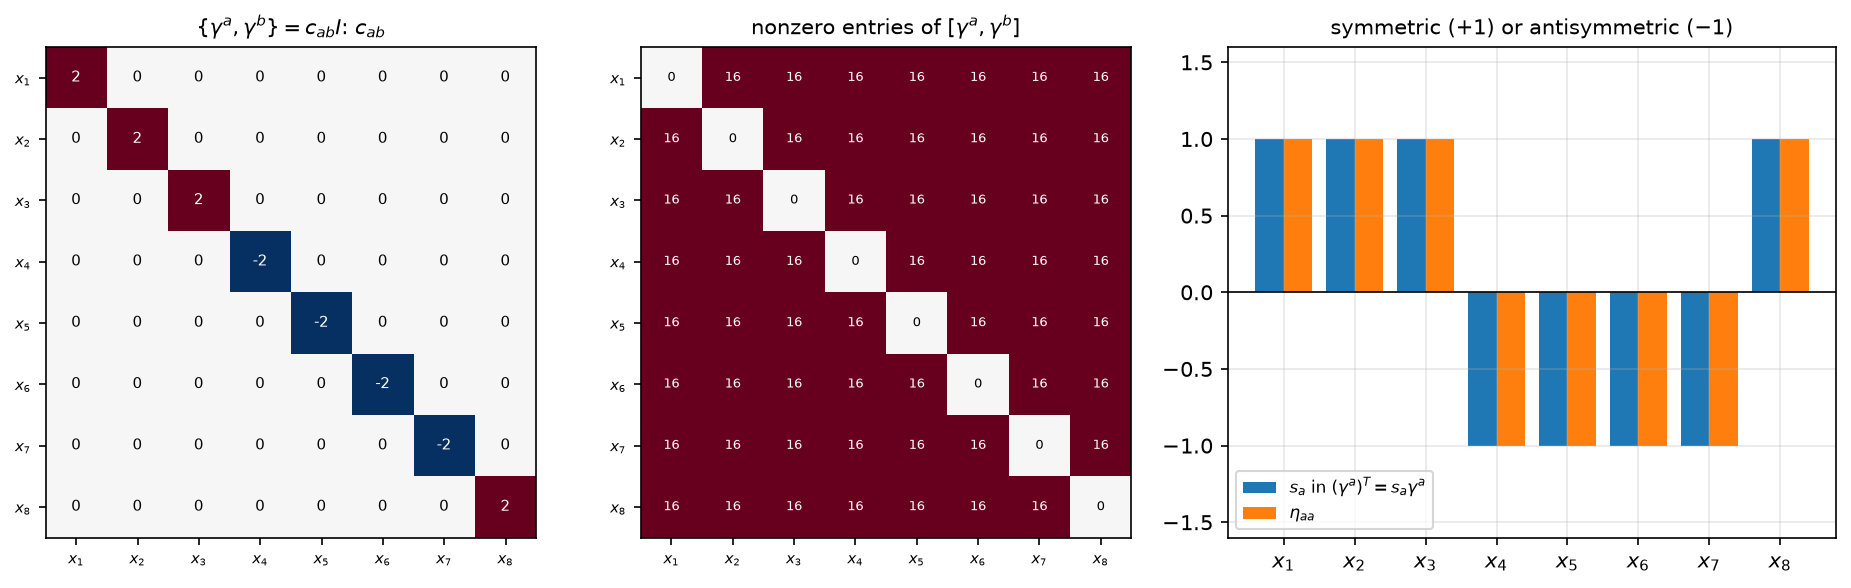

Figure 01e.4 saved as Revision/textbook/figures/01e_4_clifford_tables.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0),
                         gridspec_kw={"width_ratios": [1, 1, 1.2]})
heat_map(axes[0], anti_table, "$\\{\\gamma^a, \\gamma^b\\} = c_{ab} I$: $c_{ab}$")
heat_map(axes[1], commutator_size,
         "nonzero entries of $[\\gamma^a, \\gamma^b]$", size=6.0)
axes[2].bar(positions - 0.2, transpose_sign, width=0.4, color="tab:blue",
            label="$s_a$ in $(\\gamma^a)^T = s_a \\gamma^a$")
axes[2].bar(positions + 0.2, eta_diagonal, width=0.4, color="tab:orange",
            label="$\\eta_{aa}$")
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_xticks(positions, labels)
axes[2].set_ylim(-1.6, 1.6)
axes[2].set_title("symmetric ($+1$) or antisymmetric ($-1$)", fontsize=10)
axes[2].legend(fontsize=8, loc="lower left")
fig.tight_layout()
save_figure(fig, "clifford_tables",
            "The Clifford relation of the eight real $16 \\times 16$ gamma matrices "
            "of the Revision record. Left: the number $c_{ab}$ in "
            "$\\gamma^a\\gamma^b + \\gamma^b\\gamma^a = c_{ab} I$ for all 64 pairs "
            "(rows $a$, columns $b$, labelled $x_1$ to $x_8$): $c_{ab} = "
            "2\\eta^{ab}$, that is $+2$ or $-2$ on the diagonal and 0 elsewhere. "
            "Middle: the number of nonzero entries of the commutator "
            "$\\gamma^a\\gamma^b - \\gamma^b\\gamma^a$: 0 on the diagonal and 16 "
            "elsewhere, because different gamma matrices anticommute. Right: the "
            "sign $s_a$ with $(\\gamma^a)^T = s_a \\gamma^a$ (blue) next to "
            "$\\eta_{aa}$ (orange) for each coordinate; they agree.")

## 10. Contractions with the gamma matrices

Lowering the index of the gamma matrices gives $\gamma_a = \eta_{ab}\gamma^b$,
which is $+\gamma^a$ for a space-like and $-\gamma^a$ for a time-like
direction. Two contractions follow from the Clifford relation alone.

**First:** $\gamma^a \gamma_a = 8 I$. Line by line:

$$\gamma^a \gamma_a = \sum_a \gamma^a \eta_{ab} \gamma^b
= \sum_a \eta_{aa} (\gamma^a)^2$$

(only $b = a$ survives because $\eta$ is diagonal),

$$\sum_a \eta_{aa} (\gamma^a)^2 = \sum_a \eta_{aa} \eta^{aa} I$$

(the Clifford relation with $a = b$: $2(\gamma^a)^2 = 2\eta^{aa} I$),

$$\sum_a \eta_{aa}\eta^{aa} I = \sum_a 1 \cdot I = 8 I$$

($\eta_{aa}\eta^{aa} = (\pm 1)^2 = 1$ for each of the 8 values of $a$). Each
time-like direction contributes $(\gamma^a)^2 = -I$, but its $\eta_{aa} = -1$
turns the contribution into $+I$.

**Second:** $\gamma^a \gamma^b \gamma_a = -6\gamma^b$. First lower one index of
the Clifford relation: multiplying $\gamma^b\gamma^c + \gamma^c\gamma^b =
2\eta^{bc} I$ by $\eta_{ca}$ and summing over $c$ gives
$\gamma^b\gamma_a + \gamma_a\gamma^b = 2\delta^b_a I$, that is
$\gamma^b\gamma_a = -\gamma_a\gamma^b + 2\delta^b_a I$. Then

$$\gamma^a \gamma^b \gamma_a = \gamma^a\big(-\gamma_a\gamma^b + 2\delta^b_a
I\big) = -(\gamma^a\gamma_a)\gamma^b + 2\gamma^b = -8\gamma^b + 2\gamma^b =
-6\gamma^b$$

(the bracket was multiplied out; $\gamma^a\delta^b_a = \gamma^b$ because only
$a = b$ survives; the first contraction was used). In $n$ dimensions the same
steps give $(2 - n)\gamma^b$.

**Third:** $\mathrm{tr}(\gamma^a\gamma^b) = 16\eta^{ab}$, because
$\mathrm{tr}(\gamma^a\gamma^b) = \mathrm{tr}(\gamma^b\gamma^a)$, so
$\mathrm{tr}(\gamma^a\gamma^b) = \tfrac12\mathrm{tr}(\{\gamma^a, \gamma^b\}) =
\tfrac12 \cdot 2\eta^{ab} \cdot \mathrm{tr}\,I = 16\eta^{ab}$.

The next cell checks the three results with the matrices of the record.

In [12]:
gamma_lower = [sum(eta_lower[a, b] * gamma[b] for b in range(8)) for a in range(8)]
contraction = sum(gamma[a] @ gamma_lower[a] for a in range(8))  # gamma^a gamma_a
check((contraction == 8 * identity16).all(), "gamma^a gamma_a = 8 I")
lowered_ok = all((gamma[b] @ gamma_lower[a] + gamma_lower[a] @ gamma[b]
                  == 2 * int(a == b) * identity16).all()
                 for a, b in itertools.product(range(8), repeat=2))
sandwich = [sum(gamma[a] @ gamma[b] @ gamma_lower[a] for a in range(8))
            for b in range(8)]  # gamma^a gamma^b gamma_a for each b
factors = [int(sandwich[b][np.nonzero(gamma[b])][0]
               // gamma[b][np.nonzero(gamma[b])][0]) for b in range(8)]
say(f"gamma^a gamma^b gamma_a = c gamma^b with c = {factors} for b = x1 ... x8")
check(lowered_ok and all((sandwich[b] == -6 * gamma[b]).all() for b in range(8)),
      "gamma^b gamma_a + gamma_a gamma^b = 2 delta^b_a I, and gamma^a gamma^b "
      "gamma_a = -6 gamma^b for every b")
traces = np.array([[int(np.trace(gamma[a] @ gamma[b])) for b in range(8)]
                   for a in range(8)])
check((traces == 16 * eta_upper).all(), "tr(gamma^a gamma^b) = 16 eta^ab")

PASS gamma^a gamma_a = 8 I
gamma^a gamma^b gamma_a = c gamma^b with c = [-6, -6, -6, -6, -6, -6, -6, -6] for b = x1
    ... x8
PASS gamma^b gamma_a + gamma_a gamma^b = 2 delta^b_a I, and gamma^a gamma^b gamma_a = -6
    gamma^b for every b
PASS tr(gamma^a gamma^b) = 16 eta^ab


The next cell draws the first contraction term by term (left) and the second
for every $b$ (right).

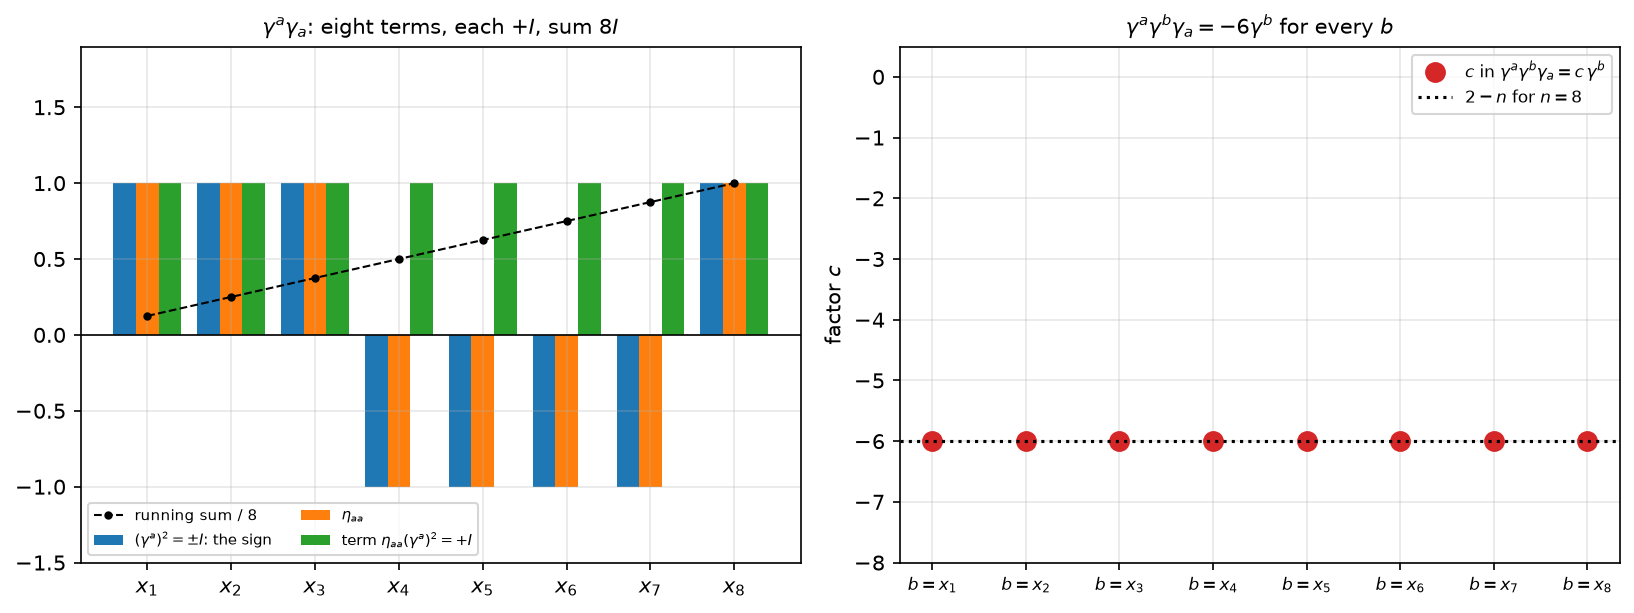

Figure 01e.5 saved as Revision/textbook/figures/01e_5_gamma_contractions.png


In [13]:
square_sign = [int(np.trace(g @ g)) // 16 for g in gamma]  # (gamma^a)^2 = +-I
term_sign = [eta_diagonal[a] * square_sign[a] for a in range(8)]  # eta_aa (gamma^a)^2
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.2))
left.bar(positions - 0.27, square_sign, width=0.27, color="tab:blue",
         label="$(\\gamma^a)^2 = \\pm I$: the sign")
left.bar(positions, eta_diagonal, width=0.27, color="tab:orange",
         label="$\\eta_{aa}$")
left.bar(positions + 0.27, term_sign, width=0.27, color="tab:green",
         label="term $\\eta_{aa}(\\gamma^a)^2 = +I$")
left.plot(positions, np.cumsum(term_sign) / 8, "k.--", lw=1,
          label="running sum / 8")
left.axhline(0, color="black", lw=0.8)
left.set_xticks(positions, labels)
left.set_ylim(-1.5, 1.9)
left.set_title("$\\gamma^a\\gamma_a$: eight terms, each $+I$, sum $8I$",
               fontsize=10)
left.legend(fontsize=7, loc="lower left", ncol=2)
right.plot(positions, factors, "o", color="tab:red", ms=9,
           label="$c$ in $\\gamma^a\\gamma^b\\gamma_a = c\\,\\gamma^b$")
right.axhline(2 - 8, color="black", ls=":", label="$2 - n$ for $n = 8$")
right.set_xticks(positions, [f"$b = x_{k}$" for k in range(1, 9)], fontsize=8)
right.set_ylim(-8.0, 0.5)
right.set_ylabel("factor $c$")
right.set_title("$\\gamma^a\\gamma^b\\gamma_a = -6\\gamma^b$ for every $b$",
                fontsize=10)
right.legend(fontsize=8, loc="upper right")
fig.tight_layout()
save_figure(fig, "gamma_contractions",
            "Left: the contraction $\\gamma^a\\gamma_a$ term by term for $a = x_1$ "
            "to $x_8$: the sign of $(\\gamma^a)^2 = \\pm I$ (blue), $\\eta_{aa}$ "
            "(orange) and their product, the term $\\eta_{aa}(\\gamma^a)^2$ "
            "(green), which is $+I$ for every $a$; the dashed line is the running "
            "sum divided by 8, which reaches 1, so the sum is $8I$. Right: the "
            "number $c$ in $\\gamma^a\\gamma^b\\gamma_a = c\\,\\gamma^b$ for each "
            "$b$ (red dots), computed with the gamma matrices of the Revision "
            "record, and the line $2 - n = -6$ for $n = 8$ dimensions (dotted); "
            "vertical axes pure numbers.")

## 11. The author's metric in index notation

The Revision record file Revision/gkd_lovelock/results/curvature.json stores
the diagonal of the author's metric as text in the notation of the program
Mathematica, for example `E^(2*a4[x4])*Sin[6*H*x8]^(1/3)`. The next cell turns
the text into sympy expressions (with the symbols $a_4$ and $z = 6 H x_8$) and
checks them against the metric of section 4. Then:

- the inverse metric of a diagonal metric is diagonal with the inverse entries,
  $g^{\mu\mu} = 1/g_{\mu\mu}$, and $g^{\mu\nu} g_{\nu\lambda} =
  \delta^\mu_\lambda$; the record's report python-lovelock-report.json checks
  this in its check `metric_inverse`;
- the squared length of a small step $dx^\mu$ is the double sum
  $ds^2 = g_{\mu\nu} dx^\mu dx^\nu$, in which only the terms $\nu = \mu$
  survive: $ds^2 = \sum_\mu g_{\mu\mu} (dx^\mu)^2$;
- for the step with the same small size $\epsilon$ in all eight coordinates,
  $dx^\mu = \epsilon$, this is

$$ds^2 = \epsilon^2\big(3e^{2a_4}s - 1 - 3e^{-2a_4}s + \cot^2 z\big)
= \epsilon^2\big(6 s \sinh(2a_4) - 1 + \cot^2 z\big),$$

because $e^{x} - e^{-x} = 2\sinh x$ with $x = 2a_4$; and lowering the index,
$dx_\mu = g_{\mu\nu} dx^\nu$, gives the same number as $dx^\mu dx_\mu$.

The cell checks all three statements exactly (in units with $\epsilon = 1$).

In [14]:
a4 = sp.Symbol("a4", real=True)  # the value of a4(x4) at one time
z = sp.Symbol("z", positive=True)  # z = 6 H x8, between 0 and pi/2
s = sp.sin(z) ** sp.Rational(1, 3)
g_typed = ([sp.exp(2 * a4) * s] * 3 + [sp.Integer(-1)]
           + [-sp.exp(-2 * a4) * s] * 3 + [sp.cot(z) ** 2])
curvature = json.loads(repository_file("Revision/gkd_lovelock/results/curvature.json")
                       .read_text(encoding="utf-8"))


def from_record(text):
    """The record's Mathematica text as a sympy expression."""
    text = text.replace("a4[x4]", "a4").replace("Sin[6*H*x8]", "sin(z)")
    text = text.replace("Cot[6*H*x8]", "cot(z)").replace("^", "**")
    return sp.sympify(text, locals={"a4": a4, "z": z, "E": sp.E})


g_record = [from_record(text) for text in curvature["metricDiagonal"]]
check(all(sp.simplify(x - y) == 0 for x, y in zip(g_record, g_typed)),
      "the record's metric diagonal is the author's metric of section 4",
      record="Revision/gkd_lovelock/results/curvature.json, metricDiagonal")
g_lower = sp.diag(*g_record)  # g_mu nu
g_upper = sp.diag(*[1 / entry for entry in g_record])  # g^mu nu
lovelock_report = json.loads(repository_file(
    "Revision/gkd_lovelock/results/python-lovelock-report.json")
    .read_text(encoding="utf-8"))
lovelock_verdicts = {c["name"]: c["verdict"] for c in lovelock_report["checks"]}
check((g_upper * g_lower).applyfunc(sp.simplify) == sp.eye(8)
      and lovelock_verdicts["metric_inverse"] == "PASS",
      "g^mu nu g_nu lambda = delta^mu_lambda",
      record="Revision/gkd_lovelock/results/python-lovelock-report.json, check "
             "metric_inverse")
step = sp.Matrix([1] * 8)  # dx^mu = 1 for every mu (units with epsilon = 1)
ds2 = (step.T * g_lower * step)[0, 0]  # g_mu nu dx^mu dx^nu
step_lower = g_lower * step  # dx_mu = g_mu nu dx^nu
ds2_contracted = (step.T * step_lower)[0, 0]  # dx^mu dx_mu
closed_form = 6 * s * sp.sinh(2 * a4) - 1 + sp.cot(z) ** 2
say(f"ds^2 for dx^mu = 1: {ds2}")
check(sp.expand((ds2 - closed_form).rewrite(sp.exp)) == 0
      and sp.expand(ds2_contracted - ds2) == 0,
      "ds^2 = 6 s sinh(2 a4) - 1 + cot(z)^2 for the step dx^mu = 1, and dx^mu dx_mu "
      "gives the same")

PASS the record's metric diagonal is the author's metric of section 4
     reproduces Revision/gkd_lovelock/results/curvature.json, metricDiagonal
PASS g^mu nu g_nu lambda = delta^mu_lambda
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, check
    metric_inverse
ds^2 for dx^mu = 1: 3*exp(2*a4)*sin(z)**(1/3) + cot(z)**2 - 1 -
    3*exp(-2*a4)*sin(z)**(1/3)
PASS ds^2 = 6 s sinh(2 a4) - 1 + cot(z)^2 for the step dx^mu = 1, and dx^mu dx_mu gives
    the same


For each $z$, $ds^2$ grows when $a_4$ grows ($\sinh$ is an increasing function
and $6s > 0$), from very negative values (time-like steps) to very positive
ones (space-like steps). It is zero where $6 s \sinh(2a_4) = 1 - \cot^2 z$,
that is at

$$a_4^{\ast}(z) = \tfrac12\,\mathrm{arcsinh}\!\left(\frac{1 - \cot^2 z}{6 s}\right),$$

where $\mathrm{arcsinh}$ undoes $\sinh$. The next cell evaluates $ds^2$ on a
grid of 301 values of $a_4$ from $-1.5$ to $1.5$ and 300 values of $z$, checks
that it grows with $a_4$ on every row of the grid and that its sign changes
exactly at $a_4^{\ast}(z)$, and draws two pictures: the sign map with the curve
$a_4^{\ast}(z)$, and at $z = 0.9$ the four kinds of terms of the sum against
$a_4$: the growing term of the three space directions, the constant term of
the time, the shrinking term of the three deflating extra times, and the
constant term of the hidden direction.

PASS on every row of the grid, ds^2 grows as a4 grows
PASS ds^2 > 0 exactly to the right of the curve a4*(z)


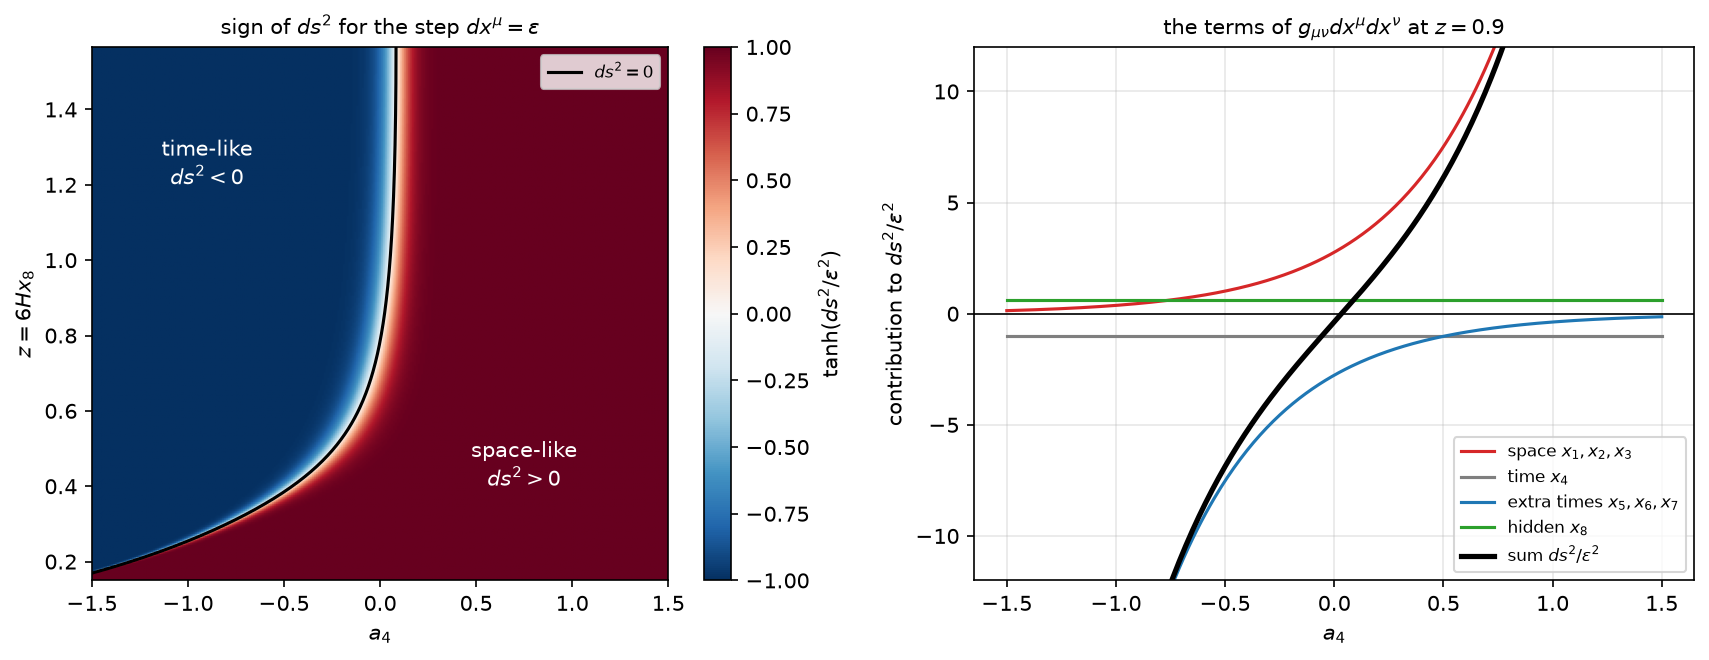

Figure 01e.6 saved as Revision/textbook/figures/01e_6_step_length.png


In [15]:
ds2_numbers = sp.lambdify((a4, z), closed_form, "numpy")  # a formula -> a function
a4_values = np.linspace(-1.5, 1.5, 301)
z_values = np.linspace(0.15, np.pi / 2 - 0.005, 300)
A4_grid, Z_grid = np.meshgrid(a4_values, z_values)  # rows: z, columns: a4
values = ds2_numbers(A4_grid, Z_grid)
threshold = 0.5 * np.arcsinh((1 - 1 / np.tan(z_values) ** 2)
                             / (6 * np.sin(z_values) ** (1 / 3)))
check(bool((np.diff(values, axis=1) > 0).all()),
      "on every row of the grid, ds^2 grows as a4 grows")
away = np.abs(A4_grid - threshold[:, None]) > 1e-9  # leave out points on the curve
check(bool(((values > 0) == (A4_grid > threshold[:, None]))[away].all()),
      "ds^2 > 0 exactly to the right of the curve a4*(z)")
fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.5))
image = left.imshow(np.tanh(values), origin="lower", aspect="auto", cmap="RdBu_r",
                    vmin=-1, vmax=1, extent=(a4_values[0], a4_values[-1],
                                             z_values[0], z_values[-1]))
left.plot(threshold, z_values, color="black", lw=1.5, label="$ds^2 = 0$")
left.set_xlim(a4_values[0], a4_values[-1])
left.grid(False)  # no grid lines across the coloured map
left.text(0.75, 0.4, "space-like\n$ds^2 > 0$", ha="center", color="white")
left.text(-0.9, 1.2, "time-like\n$ds^2 < 0$", ha="center", color="white")
left.set_xlabel("$a_4$")
left.set_ylabel("$z = 6 H x_8$")
left.set_title("sign of $ds^2$ for the step $dx^\\mu = \\epsilon$", fontsize=10)
left.legend(loc="upper right", fontsize=8)
fig.colorbar(image, ax=left, label="$\\tanh(ds^2/\\epsilon^2)$")
z_fixed = 0.9
s_fixed = np.sin(z_fixed) ** (1 / 3)
space_term = 3 * np.exp(2 * a4_values) * s_fixed  # x1, x2, x3
extra_term = -3 * np.exp(-2 * a4_values) * s_fixed  # x5, x6, x7 (deflating)
hidden_term = np.full_like(a4_values, 1 / np.tan(z_fixed) ** 2)  # x8
right.plot(a4_values, space_term, color="tab:red", label="space $x_1, x_2, x_3$")
right.plot(a4_values, np.full_like(a4_values, -1.0), color="tab:gray",
           label="time $x_4$")
right.plot(a4_values, extra_term, color="tab:blue",
           label="extra times $x_5, x_6, x_7$")
right.plot(a4_values, hidden_term, color="tab:green", label="hidden $x_8$")
right.plot(a4_values, space_term - 1 + extra_term + hidden_term, "k", lw=2.5,
           label="sum $ds^2/\\epsilon^2$")
right.axhline(0, color="black", lw=0.8)
right.set_ylim(-12, 12)
right.set_xlabel("$a_4$")
right.set_ylabel("contribution to $ds^2/\\epsilon^2$")
right.set_title(f"the terms of $g_{{\\mu\\nu}} dx^\\mu dx^\\nu$ at $z = {z_fixed}$",
                fontsize=10)
right.legend(fontsize=8, loc="lower right")
fig.tight_layout()
save_figure(fig, "step_length",
            "The squared length $ds^2 = g_{\\mu\\nu} dx^\\mu dx^\\nu$ of the "
            "coordinate step with $dx^\\mu = \\epsilon$ in all eight coordinates, "
            "in the author's metric. Left: $\\tanh(ds^2/\\epsilon^2)$ as colours "
            "(red space-like, blue time-like) against $a_4$ (horizontal) and "
            "$z = 6 H x_8$ (vertical), pure numbers, with the curve "
            "$a_4^{\\ast}(z)$ where $ds^2 = 0$ (black). Right: at $z = 0.9$ the four "
            "kinds of terms against $a_4$: the three space directions (red, growing "
            "like $e^{2a_4}$), the time (grey, $-1$), the three extra times (blue, "
            "shrinking towards 0 like $e^{-2a_4}$ as they deflate) and the hidden "
            "direction (green), and their sum (black). As $a_4$ grows the same "
            "coordinate step turns from time-like to space-like.")

## 12. The last check

The last cell checks that the six figure files of this notebook exist in the
folder Revision/textbook/figures and prints the number of checks that passed.

In [16]:
figure_names = ["01e_1_eta_and_delta.png", "01e_2_squared_lengths.png",
                "01e_3_symmetric_antisymmetric.png", "01e_4_clifford_tables.png",
                "01e_5_gamma_contractions.png", "01e_6_step_length.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_names),
      "all 6 figure files of this notebook exist")
all_checks_passed()

PASS all 6 figure files of this notebook exist
ALL 25 CHECKS PASSED (notebook 01e)


## 13. What this notebook showed

- An index that appears once in every term is free (the formula holds for each
  of its values: $8^k$ equations for $k$ free indices); an index that appears
  twice is a dummy and is summed (the summation convention). numpy's `einsum`
  evaluates such sums from the list of indices; renaming a dummy changes
  nothing.
- The frame metric of the Revision record is $\eta =
  \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$; $\eta^{ab}$ has the same
  entries, $\eta^{ab}\eta_{bc} = \delta^a_c$ and $\delta^a_a = 8$. Lowering an
  index flips the signs of the four time-like components $x_4, \dots, x_7$.
- The squared length $\eta_{ab}v^a v^b = v^a v_a$ sorts vectors into
  space-like, time-like and light-like ones; in the signature (4,4) exchanging
  the space-like and the time-like components turns $Q$ into $-Q$, so exactly
  half of all random vectors are space-like (measured: 0.50), while in ordinary
  spacetime about 82 per cent are.
- A symmetric array contracted with an antisymmetric one gives 0; so only the
  symmetric part of an array counts in $v^a v^b M_{ab}$ for commuting
  components.
- The eight gamma matrices of the Revision record obey
  $\{\gamma^a, \gamma^b\} = 2\eta^{ab} I$ for all 64 pairs; they are orthogonal,
  symmetric for the space-like and antisymmetric for the time-like directions;
  and $\gamma^a\gamma_a = 8I$, $\gamma^a\gamma^b\gamma_a = -6\gamma^b$,
  $\mathrm{tr}(\gamma^a\gamma^b) = 16\eta^{ab}$, derived line by line and
  checked.
- In the author's metric the step $dx^\mu = \epsilon$ has
  $ds^2 = \epsilon^2(6 s\sinh(2a_4) - 1 + \cot^2 z)$; as $a_4$ grows, the term
  of the three space directions grows like $e^{2a_4}$ and the term of the
  three exponentially deflating extra times shrinks like $e^{-2a_4}$, and the
  step turns from time-like to space-like at $a_4^{\ast}(z)$.